In [19]:
#mounting google drive with data set
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
#loading up the data set
df = pd.read_csv('/content/drive/MyDrive/fifa_eda_stats.csv')
print(df.shape)

(18207, 57)


In [22]:
#checking first 5 rows
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [23]:
#checking the columns
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
       'Release Clause'],
      dtype='object')

In [24]:
#checking the type of data fo r the columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     18207 non-null  object 
 8   Wage                      18207 non-null  object 
 9   Preferred Foot            18159 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Weak Foot                 18159 non-null  float64
 12  Skill Moves               18159 non-null  float64
 13  Work Rate                 18159 non-null  object 
 14  Body T

In [25]:
#checking blanks
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Nationality,0
Overall,0
Potential,0
Club,241
Value,0
Wage,0
Preferred Foot,48


In [26]:
#carrying out statistical calculations based on the overall of the players
df['Overall'].describe()

,Overall
count,18207.000000
mean,66.238699
std,6.908930
min,46.000000
25%,62.000000
50%,66.000000
75%,71.000000
max,94.000000


In [27]:
#checking dtype of wages before conversion
df['Wage'].head(10)

,Wage
0,€565K
1,€405K
2,€290K
3,€260K
4,€355K
5,€340K
6,€420K
7,€455K
8,€380K
9,€94K


In [28]:
#Data cleaning
def clean_wage(value):
  if pd.isna(value):
    return 0
  value=str(value).replace('€','').replace('K','').strip()
  return float(value)*1000
df['Wage_clean']=df['Wage'].apply(clean_wage)
df['Wage_clean'].head(10)


,Wage_clean
0,565000.0
1,405000.0
2,290000.0
3,260000.0
4,355000.0
5,340000.0
6,420000.0
7,455000.0
8,380000.0
9,94000.0


In [31]:
# Clean the wage column
def clean_wage(value):
    if pd.isna(value):
        return 0
    value = str(value).replace('€', '').replace('K', '').strip()
    return float(value) * 1000

df['Wage_Clean'] = df['Wage'].apply(clean_wage)

# verification of wage clean column made after data cleaning
print('Lowest wage:', df['Wage_Clean'].min())
print('Highest wage:', df['Wage_Clean'].max())
print('Average wage:', df['Wage_Clean'].mean())

Lowest wage: 0.0
Highest wage: 565000.0
Average wage: 9731.312132696215


In [33]:
#Q1. WHAT IS THE MOST PLAYED POSITION
position_counts = df['Position'].value_counts()
print(position_counts.head(10))

Position
ST     2152
GK     2025
CB     1778
CM     1394
LB     1322
RB     1291
RM     1124
LM     1095
CAM     958
CDM     948
Name: count, dtype: int64


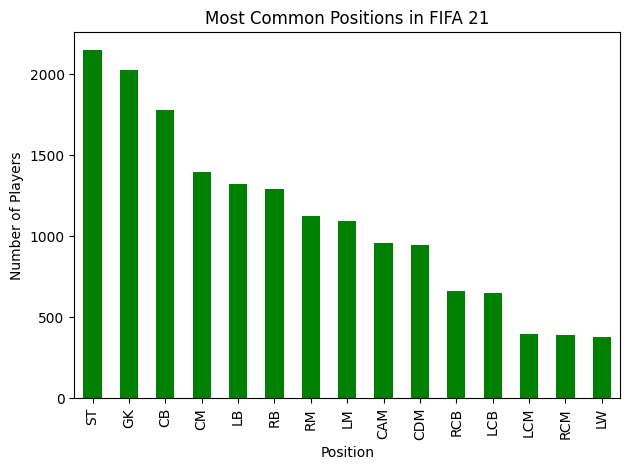

In [42]:


position_counts.head(15).plot(kind='bar', color='Green')
plt.title('Most Common Positions in FIFA 21')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

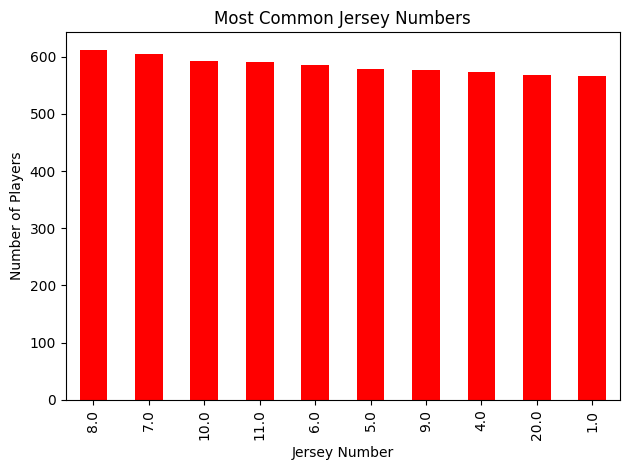

In [41]:
#Q2 MOST COMMON JERSEY NUMBER
jersey_counts = df['Jersey Number'].value_counts()
jersey_counts.head(10).plot(kind='bar', color='red')
plt.title('Most Common Jersey Numbers')
plt.xlabel('Jersey Number')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

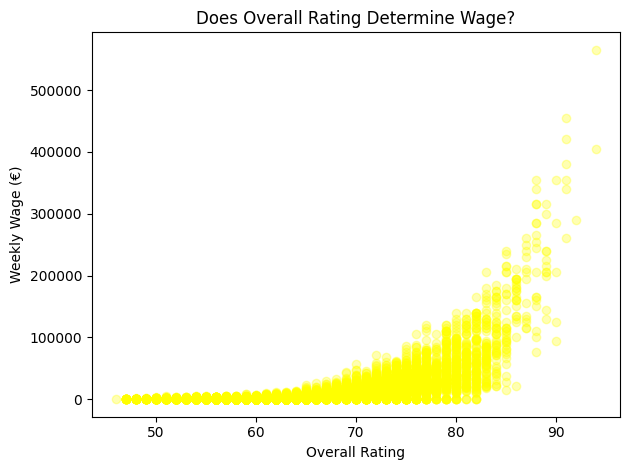

Correlation: 0.5719260112876148


In [43]:
#Q3.OVERALL RELATION WITH WAGE
plt.scatter(df['Overall'], df['Wage_Clean'], alpha=0.3, color='yellow')
plt.title('Does Overall Rating Determine Wage?')
plt.xlabel('Overall Rating')
plt.ylabel('Weekly Wage (€)')
plt.tight_layout()
plt.show()
print('Correlation:', df['Overall'].corr(df['Wage_Clean']))

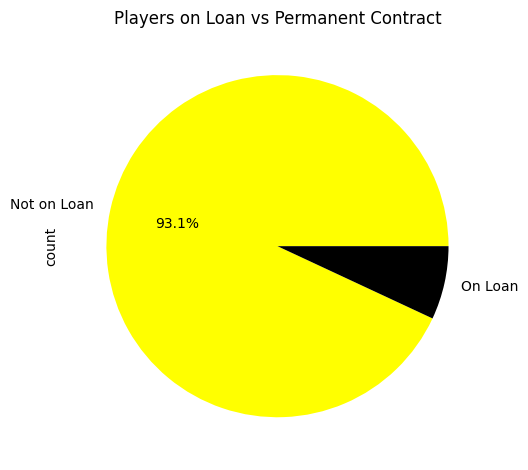

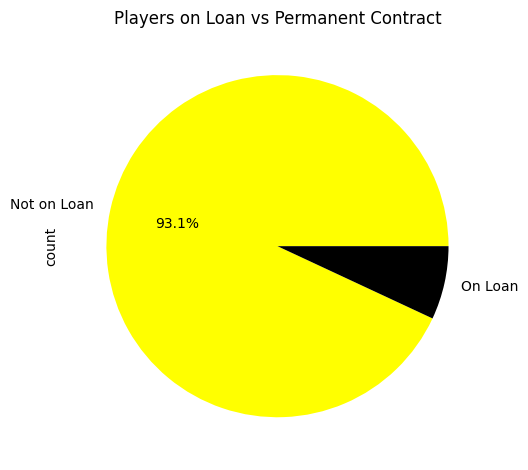

In [46]:
#Q4
df['On_Loan'] = df['Loaned From'].notna()
df['On_Loan'].value_counts().plot(kind='pie',
    labels=['Not on Loan', 'On Loan'],
    autopct='%1.1f%%',
    colors=['yellow', 'black'])
plt.title('Players on Loan vs Permanent Contract')
plt.tight_layout()
plt.show()

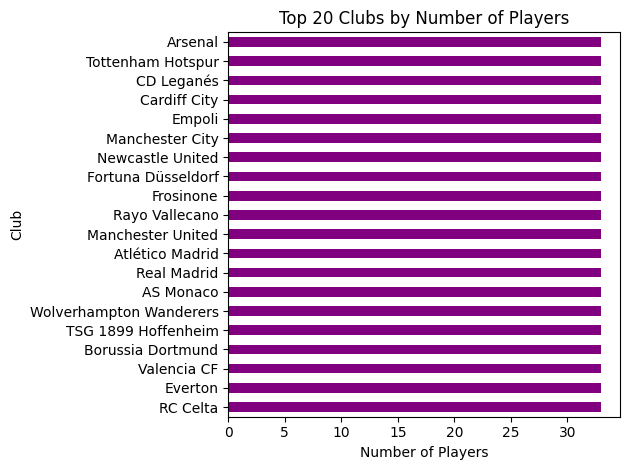

In [49]:
#Q5

df['Club'].value_counts().head(20).plot(kind='barh', color='PURPLE')
plt.title('Top 20 Clubs by Number of Players')
plt.xlabel('Number of Players')
plt.tight_layout()
plt.show()